Accuracy (Decision Tree): 1.0


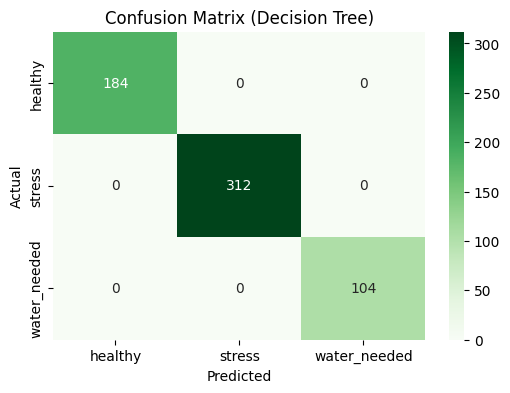

Plant condition (Decision Tree): healthy


In [1]:
%matplotlib inline

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier  # <-- XGBoost ki jagah ye use hoga
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
data = pd.read_csv("plant_data_7params_3000.csv")

X = data[['moisture','temperature','humidity','light','ph','air_quality','nutrient']]
y = data['label']

# 2. Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Data Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# 4. Decision Tree Model
# random_state=42 isliye taaki result hamesha same aaye
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 5. Predictions & Accuracy
y_pred_dt = dt_model.predict(X_test)
print("Accuracy (Decision Tree):", accuracy_score(y_test, y_pred_dt))

# 6. Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Green color for Decision Tree
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Decision Tree)")
plt.show()

# 7. Manual prediction
new_data = pd.DataFrame(
    [[200, 30, 50, 500, 6.5, 400, 60]],
    columns=['moisture','temperature','humidity','light','ph','air_quality','nutrient']
)

# Predict and convert back to text
prediction_numeric = dt_model.predict(new_data)
prediction_text = le.inverse_transform(prediction_numeric)

print("Plant condition (Decision Tree):", prediction_text[0])